In [1]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, shutil, random
from PIL import Image

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


### 0.1 Download the Fruit Dataset

We use a subset of the **Fruits-360** dataset, keeping only apples and oranges.
The images are 100×100 RGB — we'll resize to 64×64 for faster training.

In [2]:
# download & prepare dataset

!pip install -q kagglehub
import kagglehub
dataset_path = kagglehub.dataset_download("moltean/fruits")

Using Colab cache for faster access to the 'fruits' dataset.


In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("moltean/fruits")
print(f"Dataset downloaded to: {dataset_path}")

# Show apple/orange directories
import subprocess
result = subprocess.run(['find', dataset_path, '-maxdepth', '3', '-type', 'd'],
                       capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if any(fruit in line.lower() for fruit in ['apple', 'orange', 'training', 'test']):
        print(line)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset downloaded to: /kaggle/input/fruits
/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
/kaggle/input/fruits/fruits-360_100x100/fruits-360/Test
/kaggle/input/fruits/fruits-360_3-body-problem/fruits-360-3-body-problem/Training
/kaggle/input/fruits/fruits-360_3-body-problem/fruits-360-3-body-problem/Test
/kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Training
/kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Test
/kaggle/input/fruits/fruits-360_multi/test-multiple_fruits


In [4]:
def prepare_fruit_dataset(source_root, dest_root='./fruit_data', balance=True):
    """
    Extract apple and orange images from Fruits-360.
    - Excludes Pepper Orange, Pineapple, peeled oranges
    - Optionally downsamples the larger class to match the smaller one
    """
    # Clean start if re-running
    if os.path.exists(dest_root):
        shutil.rmtree(dest_root)
    os.makedirs(dest_root)

    APPLE_KEYWORDS = ['apple']
    APPLE_EXCLUDE  = ['pineapple', 'custard']
    ORANGE_KEYWORDS = ['orange']
    ORANGE_EXCLUDE  = ['pepper', 'cherry', 'peeled']

    def classify_folder(name):
        name_lower = name.lower()
        if any(kw in name_lower for kw in APPLE_KEYWORDS):
            if not any(ex in name_lower for ex in APPLE_EXCLUDE):
                return 'apple'
        if any(kw in name_lower for kw in ORANGE_KEYWORDS):
            if not any(ex in name_lower for ex in ORANGE_EXCLUDE):
                return 'orange'
        return None

    for split_src, split_dst in [('Training', 'train'), ('Test', 'test')]:
        src_base = os.path.join(source_root, split_src)
        if not os.path.exists(src_base):
            for candidate in Path(source_root).rglob(split_src):
                if candidate.is_dir():
                    src_base = str(candidate)
                    break
        if not os.path.exists(src_base):
            print(f"Warning: Could not find {split_src} directory")
            continue

        for class_dir in sorted(os.listdir(src_base)):
            target_class = classify_folder(class_dir)
            if target_class is None:
                continue

            print(f"  ✅ {split_dst}: '{class_dir}' → {target_class}")

            src_dir = os.path.join(src_base, class_dir)
            dst_dir = os.path.join(dest_root, split_dst, target_class)
            os.makedirs(dst_dir, exist_ok=True)

            for img_file in os.listdir(src_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(src_dir, img_file)
                    dst_name = f"{class_dir}_{img_file}"
                    dst_path = os.path.join(dst_dir, dst_name)
                    if not os.path.exists(dst_path):
                        shutil.copy2(src_path, dst_path)

    # === Balance classes by downsampling the larger one ===
    if balance:
        print(f"\n⚖️  Balancing classes...")
        for split in ['train', 'test']:
            split_dir = os.path.join(dest_root, split)
            if not os.path.exists(split_dir):
                continue

            # Count per class
            class_counts = {}
            class_files = {}
            for cls in sorted(os.listdir(split_dir)):
                cls_dir = os.path.join(split_dir, cls)
                files = [f for f in os.listdir(cls_dir)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                class_counts[cls] = len(files)
                class_files[cls] = files

            min_count = min(class_counts.values())
            print(f"  {split}: min class has {min_count} images, downsampling others to match")

            for cls, files in class_files.items():
                if len(files) > min_count:
                    # Randomly select which files to REMOVE
                    random.seed(SEED)  # reproducible
                    keep = set(random.sample(files, min_count))
                    removed = 0
                    for f in files:
                        if f not in keep:
                            os.remove(os.path.join(split_dir, cls, f))
                            removed += 1
                    print(f"    {cls}: removed {removed} images, kept {min_count}")

    # Print final summary
    print(f"\n📊 Final Dataset Summary:")
    print(f"{'─' * 40}")
    for split in ['train', 'test']:
        split_dir = os.path.join(dest_root, split)
        if os.path.exists(split_dir):
            for cls in sorted(os.listdir(split_dir)):
                cls_dir = os.path.join(split_dir, cls)
                n = len([f for f in os.listdir(cls_dir)
                         if f.endswith(('.jpg', '.jpeg', '.png'))])
                print(f"  {split:>5}/{cls:<10}: {n:>5} images")

    return dest_root

DATA_ROOT = prepare_fruit_dataset(dataset_path, balance=True)

  ✅ train: 'Apple 10' → apple
  ✅ train: 'Apple 11' → apple
  ✅ train: 'Apple 12' → apple
  ✅ train: 'Apple 13' → apple
  ✅ train: 'Apple 14' → apple
  ✅ train: 'Apple 17' → apple
  ✅ train: 'Apple 18' → apple
  ✅ train: 'Apple 19' → apple
  ✅ train: 'Apple 20' → apple
  ✅ train: 'Apple 21' → apple
  ✅ train: 'Apple 22' → apple
  ✅ train: 'Apple 23' → apple
  ✅ train: 'Apple 5' → apple
  ✅ train: 'Apple 6' → apple
  ✅ train: 'Apple 7' → apple
  ✅ train: 'Apple 8' → apple
  ✅ train: 'Apple 9' → apple
  ✅ train: 'Apple Braeburn 1' → apple
  ✅ train: 'Apple Crimson Snow 1' → apple
  ✅ train: 'Apple Golden 1' → apple
  ✅ train: 'Apple Golden 2' → apple
  ✅ train: 'Apple Golden 3' → apple
  ✅ train: 'Apple Granny Smith 1' → apple
  ✅ train: 'Apple Pink Lady 1' → apple
  ✅ train: 'Apple Red 1' → apple
  ✅ train: 'Apple Red 2' → apple
  ✅ train: 'Apple Red 3' → apple
  ✅ train: 'Apple Red Delicious 1' → apple
  ✅ train: 'Apple Red Yellow 1' → apple
  ✅ train: 'Apple Red Yellow 2' → apple
  ✅ 

In [24]:
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 120
LEARNING_RATE = 2e-4
NUM_TIMESTEPS = 500
EMBED_DIM = 128
BASE_CHANNELS = 64

In [25]:
# Data transforms and loading
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=transform)
test_dataset  = ImageFolder(os.path.join(DATA_ROOT, 'test'),  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = {v: k for k, v in train_dataset.class_to_idx.items()}
print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"Index → Name: {CLASS_NAMES}")

Classes: {0: 'apple', 1: 'orange'}
Train: 3794, Test: 1256
Index → Name: {0: 'apple', 1: 'orange'}


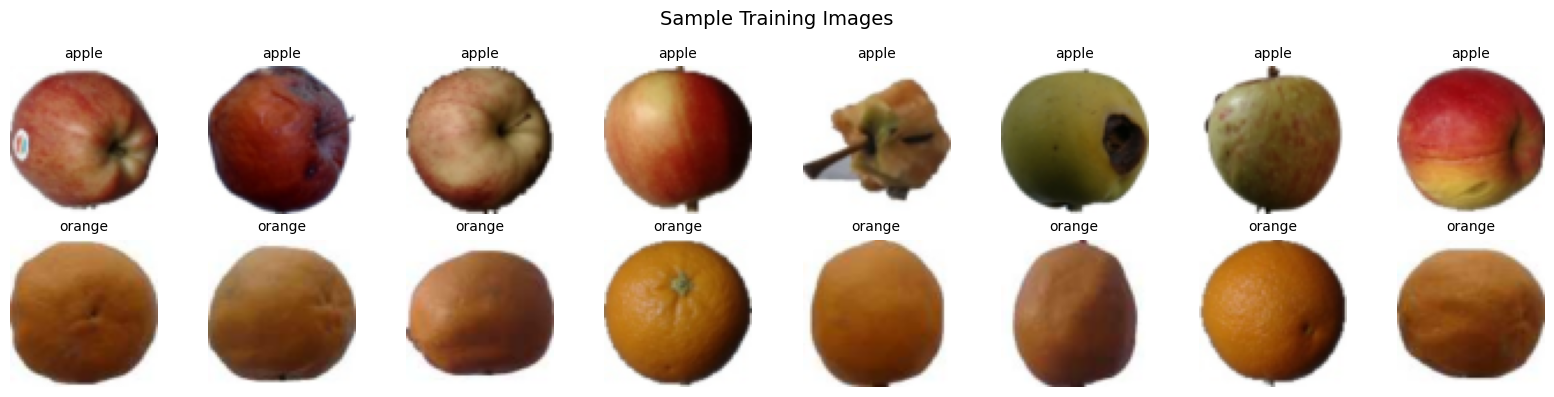

In [26]:
def show_batch(loader, n=8):
    """Display a batch of images with their labels."""
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    fig.suptitle('Sample Training Images', fontsize=14)

    for row, class_idx in enumerate([0, 1]):
        mask = labels == class_idx
        class_imgs = images[mask][:n]
        for col in range(min(n, len(class_imgs))):
            axes[row, col].imshow(class_imgs[col].permute(1, 2, 0).numpy())
            axes[row, col].set_title(CLASS_NAMES[class_idx], fontsize=10)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_batch(train_loader)

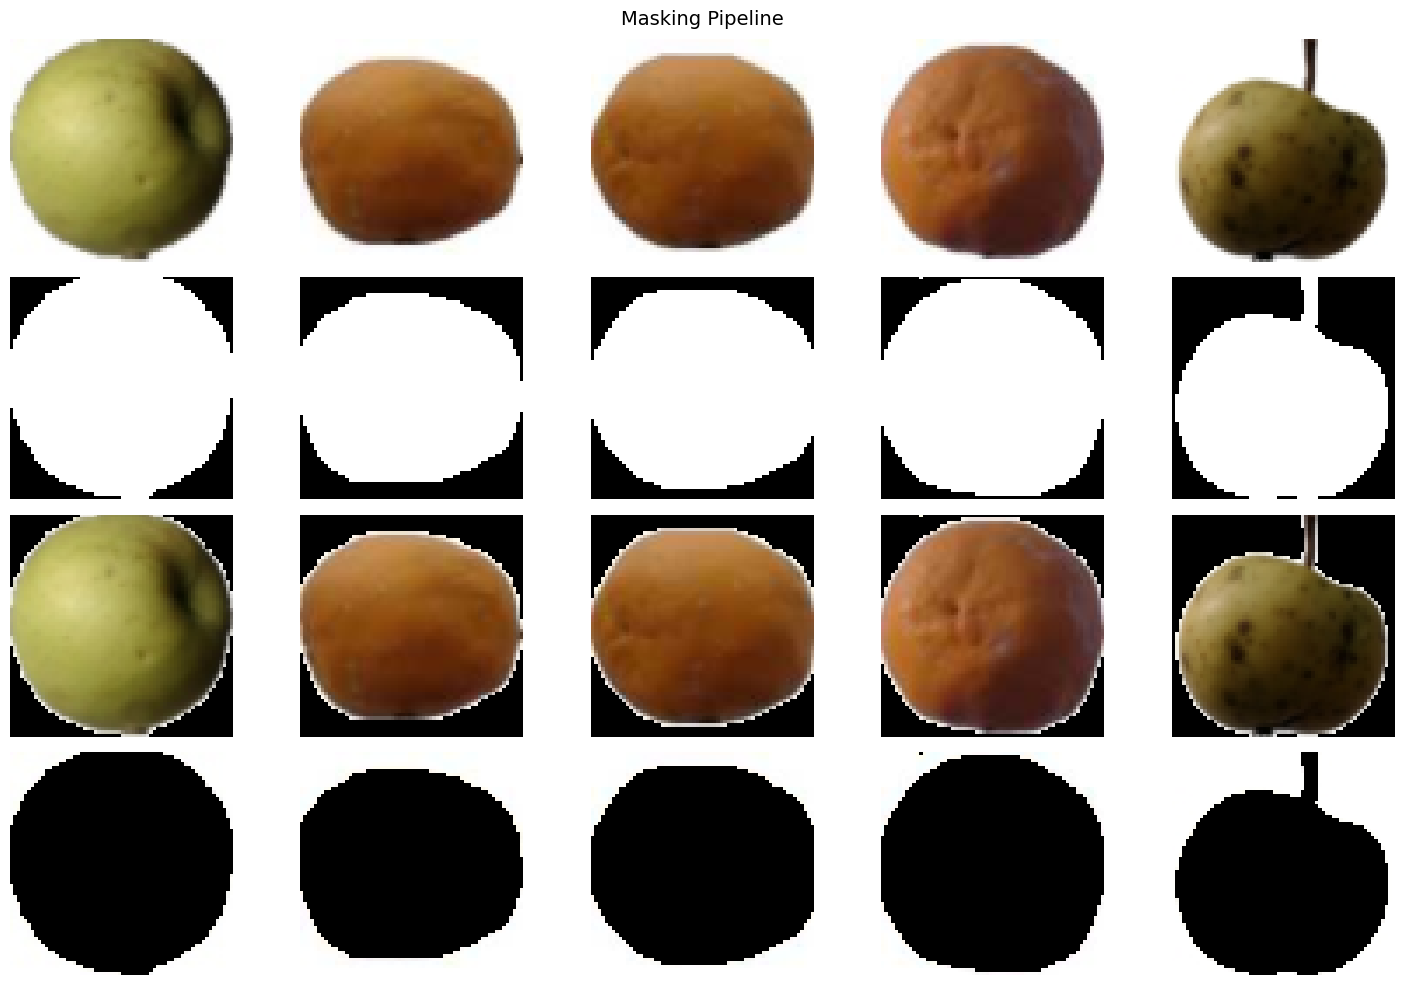

In [27]:
# === CELL 4: Masking Function (Phase 1 — no neural network) ===

def create_mask_and_crop_batch(images, threshold=0.93):
    """
    Batch masking for Fruits-360 white-background images.

    Args:
        images: (B, 3, H, W) tensor in [0, 1]
        threshold: pixels where all RGB channels > threshold = background

    Returns:
        masks:    (B, 1, H, W) — 1 where fruit is, 0 where background
        crops:    (B, 3, H, W) — fruit pixels only, background zeroed
        redacted: (B, 3, H, W) — background only, fruit area zeroed
    """
    # All channels above threshold → background
    is_background = (images > threshold).all(dim=1, keepdim=True)  # (B, 1, H, W)
    masks = (~is_background).float()

    crops = images * masks           # keep fruit, zero background
    redacted = images * (1 - masks)  # keep background, zero fruit

    return masks, crops, redacted


def visualize_masking(images, n=5):
    """Show masking results for a few samples."""
    masks, crops, redacted = create_mask_and_crop_batch(images[:n])

    fig, axes = plt.subplots(4, n, figsize=(3*n, 10))
    row_labels = ['Original', 'Mask', 'Crop (fruit)', 'Redacted (hole)']

    for i in range(n):
        axes[0, i].imshow(images[i].permute(1, 2, 0).numpy())
        axes[1, i].imshow(masks[i, 0].numpy(), cmap='gray')
        axes[2, i].imshow(crops[i].permute(1, 2, 0).numpy())
        axes[3, i].imshow(redacted[i].permute(1, 2, 0).numpy())
        for row in range(4):
            axes[row, i].axis('off')

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=70, va='center')

    plt.suptitle('Masking Pipeline', fontsize=14)
    plt.tight_layout()
    plt.show()

# Test it
sample_imgs, _ = next(iter(train_loader))
visualize_masking(sample_imgs)

In [28]:
# === CELL 5: Fruit Encoder (Phase 2) ===

class FruitEncoder(nn.Module):
    """
    Encodes a cropped fruit image into a conditioning embedding.
    This embedding tells the diffusion U-Net WHICH fruit to generate.
    Trained jointly with the U-Net.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),  nn.GroupNorm(8, 32),  nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.GroupNorm(8, 64),  nn.GELU(),
            nn.Conv2d(64, 128, 3, 2, 1),nn.GroupNorm(8, 128), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, embed_dim),
        )

    def forward(self, x):
        return self.net(x)  # (B, embed_dim)

# Quick test
enc = FruitEncoder().to(device)
dummy = torch.randn(4, 3, 64, 64).to(device)
print(f"Encoder output shape: {enc(dummy).shape}")  # should be (4, 128)

Encoder output shape: torch.Size([4, 128])


In [29]:
# === CELL 6: Building Blocks for U-Net ===

class SinusoidalPosEmb(nn.Module):
    """Sinusoidal timestep embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = torch.log(torch.tensor(10000.0, device=t.device)) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ConvBlock(nn.Module):
    """Double conv with GroupNorm and GELU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

In [30]:
class CrossAttention(nn.Module):
    """
    Cross-attention conditioning for the U-Net.

    The U-Net features (Q) attend to the conditioning embedding (K, V).
    Each spatial location in the feature map asks: "given this fruit
    embedding, what should I generate here?"

    The conditioning vector is projected into num_tokens synthetic tokens
    so the attention has multiple key-value pairs to attend to.
    """
    def __init__(self, feature_dim, embed_dim=EMBED_DIM, num_heads=4, num_tokens=4):
        super().__init__()
        self.num_heads = num_heads
        self.num_tokens = num_tokens
        self.head_dim = feature_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Project conditioning embedding → K, V tokens
        # Single vector → (num_tokens, feature_dim) sequence
        self.to_kv_tokens = nn.Sequential(
            nn.Linear(embed_dim, feature_dim * num_tokens),
            nn.GELU(),
            nn.Linear(feature_dim * num_tokens, feature_dim * num_tokens * 2),
        )

        # Q comes from the U-Net feature map
        self.to_q = nn.Linear(feature_dim, feature_dim)

        # Output projection
        self.to_out = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.GELU(),
        )

        # Layer norm for stability
        self.norm_features = nn.LayerNorm(feature_dim)
        self.norm_out = nn.LayerNorm(feature_dim)

    def forward(self, x, cond):
        """
        x:    (B, C, H, W) — U-Net feature map
        cond: (B, embed_dim) — combined time + fruit embedding

        Returns: (B, C, H, W) — modulated feature map
        """
        B, C, H, W = x.shape
        residual = x

        # Reshape feature map to sequence: (B, H*W, C)
        x_flat = x.permute(0, 2, 3, 1).reshape(B, H * W, C)
        x_flat = self.norm_features(x_flat)

        # Q from features: (B, H*W, C)
        q = self.to_q(x_flat)

        # K, V from conditioning: (B, num_tokens, C) each
        kv = self.to_kv_tokens(cond)                          # (B, C * num_tokens * 2)
        kv = kv.reshape(B, self.num_tokens, 2, C)             # (B, num_tokens, 2, C)
        k, v = kv[:, :, 0], kv[:, :, 1]                      # each (B, num_tokens, C)

        # Reshape for multi-head attention
        # (B, num_heads, seq_len, head_dim)
        q = q.reshape(B, H * W, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = k.reshape(B, self.num_tokens, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = v.reshape(B, self.num_tokens, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        # Attention: (B, heads, H*W, num_tokens)
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        # Apply attention to values: (B, heads, H*W, head_dim)
        out = torch.matmul(attn, v)

        # Reshape back: (B, H*W, C)
        out = out.permute(0, 2, 1, 3).reshape(B, H * W, C)
        out = self.to_out(out)
        out = self.norm_out(out)

        # Reshape to spatial + residual connection
        out = out.reshape(B, H, W, C).permute(0, 3, 1, 2)
        return residual + out

In [31]:
class ConditionedUNet(nn.Module):
    """
    U-Net for noise prediction in pixel-space diffusion.

    Spatial conditioning: redacted image (3ch) + mask (1ch) concatenated
                          with noisy image (3ch) → 7 input channels
    Semantic conditioning: fruit embedding
    Time conditioning:     sinusoidal embedding added to fruit embedding
    """
    def __init__(self, in_channels=7, out_channels=3,
                 base_ch=BASE_CHANNELS, embed_dim=EMBED_DIM):
        super().__init__()
        ch = base_ch  # 64

        # --- Time + condition embedding ---
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(ch),
            nn.Linear(ch, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

        # --- Encoder ---
        self.enc1 = ConvBlock(in_channels, ch)        # 64 channels
        self.enc2 = ConvBlock(ch, ch * 2)             # 128
        self.enc3 = ConvBlock(ch * 2, ch * 4)         # 256

        self.down = nn.MaxPool2d(2)

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(ch * 4, ch * 4)   # 256

        # --- Decoder ---
        self.up3 = nn.ConvTranspose2d(ch * 4, ch * 4, 2, 2)
        self.dec3 = ConvBlock(ch * 8, ch * 2)         # skip: 256+256=512 → 128

        self.up2 = nn.ConvTranspose2d(ch * 2, ch * 2, 2, 2)
        self.dec2 = ConvBlock(ch * 4, ch)             # skip: 128+128=256 → 64

        self.up1 = nn.ConvTranspose2d(ch, ch, 2, 2)
        self.dec1 = ConvBlock(ch * 2, ch)             # skip: 64+64=128 → 64

        self.out_conv = nn.Conv2d(ch, out_channels, 1)

        self.attn_enc2 = CrossAttention(feature_dim=ch * 2, embed_dim=embed_dim)
        self.attn_bottleneck = CrossAttention(feature_dim=ch * 4, embed_dim=embed_dim)
        self.attn_dec2 = CrossAttention(feature_dim=ch, embed_dim=embed_dim)

    def forward(self, x_noisy, t, redacted, mask, fruit_embed):
        """
        x_noisy:     (B, 3, H, W)
        t:           (B,) timestep indices
        redacted:    (B, 3, H, W) background with fruit masked
        mask:        (B, 1, H, W) binary mask
        fruit_embed: (B, embed_dim) from FruitEncoder
        """
        # Combine time and fruit conditioning
        t_emb = self.time_mlp(t)             # (B, embed_dim)
        cond = t_emb + fruit_embed           # (B, embed_dim)

        # Spatial input: concat noisy image + redacted + mask
        x = torch.cat([x_noisy, redacted, mask], dim=1)  # (B, 7, H, W)

        # Encoder
        e1 = self.enc1(x)                    # (B, 64, 64, 64)
        e2 = self.enc2(self.down(e1))        # (B, 128, 32, 32)
        e2 = self.attn_enc2(e2, cond)
        e3 = self.enc3(self.down(e2))        # (B, 256, 16, 16)

        # Bottleneck
        b = self.bottleneck(self.down(e3))   # (B, 256, 8, 8)
        b = self.attn_bottleneck(b, cond)

        # Decoder + skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))   # (B, 128, 16, 16)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))  # (B, 64, 32, 32)
        d2 = self.attn_dec2(d2, cond)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # (B, 64, 64, 64)

        return self.out_conv(d1)  # (B, 3, 64, 64) predicted noise


# Smoke test
unet = ConditionedUNet().to(device)
total_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parameters: {total_params:,}")

dummy_noisy = torch.randn(2, 3, 64, 64).to(device)
dummy_t = torch.tensor([10, 200]).to(device)
dummy_redact = torch.randn(2, 3, 64, 64).to(device)
dummy_mask = torch.ones(2, 1, 64, 64).to(device)
dummy_emb = torch.randn(2, EMBED_DIM).to(device)

out = unet(dummy_noisy, dummy_t, dummy_redact, dummy_mask, dummy_emb)
print(f"U-Net output shape: {out.shape}")  # (2, 3, 64, 64)
print("U-Net test passed! ✅")

U-Net parameters: 6,895,939
U-Net output shape: torch.Size([2, 3, 64, 64])
U-Net test passed! ✅


In [32]:
# === CELL 8: DDPM Noise Scheduler ===

class DDPMScheduler:
    """
    Handles the forward (noising) and reverse (denoising) diffusion process.
    """
    def __init__(self, num_timesteps=NUM_TIMESTEPS,
                 beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.num_timesteps = num_timesteps
        self.device = device

        betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

    def add_noise(self, x_0, t, noise=None):
        """q(x_t | x_0): add noise to clean image."""
        if noise is None:
            noise = torch.randn_like(x_0)

        sqrt_alpha = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]

        x_t = sqrt_alpha * x_0 + sqrt_one_minus * noise
        return x_t, noise

    @torch.no_grad()
    def sample_step(self, model, x_t, t_val, redacted, mask, fruit_embed):
        """Single reverse step: x_t → x_{t-1}"""
        B = x_t.shape[0]
        t = torch.full((B,), t_val, device=self.device, dtype=torch.long)

        pred_noise = model(x_t, t, redacted, mask, fruit_embed)

        alpha_t = self.alphas[t_val]
        alpha_bar_t = self.alphas_cumprod[t_val]
        beta_t = self.betas[t_val]

        coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x_t - coeff * pred_noise)

        if t_val > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.sqrt(beta_t) * noise
        else:
            x_t = mean

        return x_t

    @torch.no_grad()
    def sample(self, model, fruit_encoder, crop, redacted, mask,
               return_intermediates=False, intermediate_steps=10):
        """
        Full reverse process: z_T → z_0

        If return_intermediates=True, saves snapshots every N steps
        for visualization of the denoising progression.
        """
        shape = redacted.shape
        x = torch.randn(shape, device=self.device)

        fruit_embed = fruit_encoder(crop)

        intermediates = []
        save_every = self.num_timesteps // intermediate_steps

        for t_val in reversed(range(self.num_timesteps)):
            x = self.sample_step(model, x, t_val, redacted, mask, fruit_embed)

            if return_intermediates and (t_val % save_every == 0 or t_val == 0):
                intermediates.append(x.cpu().clone())

        if return_intermediates:
            return x, intermediates
        return x

In [33]:
class EMA:
    """
    Exponential Moving Average of model parameters.
    ema_weights = decay * ema_weights + (1 - decay) * model_weights

    Higher decay (e.g. 0.999) = slower update = smoother but lags behind.
    """
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {name: param.clone().detach()
                       for name, param in model.named_parameters()}

    def update(self, model):
        """Call this after each optimizer step."""
        for name, param in model.named_parameters():
            self.shadow[name].mul_(self.decay).add_(param.data, alpha=1 - self.decay)

    def apply(self, model):
        """Swap model weights with EMA weights (for inference)."""
        self.backup = {name: param.clone()
                       for name, param in model.named_parameters()}
        for name, param in model.named_parameters():
            param.data.copy_(self.shadow[name])

    def restore(self, model):
        """Restore original weights (after inference)."""
        for name, param in model.named_parameters():
            param.data.copy_(self.backup[name])

In [34]:
# === CELL 9: Training Loop ===

def train_diffusion(unet, fruit_encoder, scheduler, train_loader,
                    device, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """Train U-Net and FruitEncoder jointly."""

    optimizer = optim.Adam(
        list(unet.parameters()) + list(fruit_encoder.parameters()), lr=lr
    )
    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = []
    ema = EMA(unet, decay=0.999)
    for epoch in range(1, num_epochs + 1):
        unet.train()
        fruit_encoder.train()
        epoch_loss = 0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            B = images.size(0)

            # Phase 1: mask (batched, on device)
            masks, crops, redacted = create_mask_and_crop_batch(images)

            # Phase 2: fruit embedding
            fruit_embed = fruit_encoder(crops)

            # Phase 3: diffusion training step
            t = torch.randint(0, scheduler.num_timesteps, (B,), device=device)
            noise = torch.randn_like(images)
            x_noisy, _ = scheduler.add_noise(images, t, noise)

            # Predict noise
            pred_noise = unet(x_noisy, t, redacted, masks, fruit_embed)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ema.update(unet)

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)
        scheduler_lr.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3}/{num_epochs} | Loss: {avg_loss:.4f}")

    return history

In [35]:
# === CELL 10: Initialize & Train ===

unet = ConditionedUNet().to(device)
fruit_encoder = FruitEncoder().to(device)
scheduler = DDPMScheduler(device=device)

print(f"U-Net params:    {sum(p.numel() for p in unet.parameters()):,}")
print(f"Encoder params:  {sum(p.numel() for p in fruit_encoder.parameters()):,}")
print(f"Starting training...\n")

history = train_diffusion(unet, fruit_encoder, scheduler, train_loader, device)

U-Net params:    6,895,939
Encoder params:  110,208
Starting training...

Epoch   1/120 | Loss: 0.2053
Epoch   5/120 | Loss: 0.0246
Epoch  10/120 | Loss: 0.0174
Epoch  15/120 | Loss: 0.0135
Epoch  20/120 | Loss: 0.0133
Epoch  25/120 | Loss: 0.0101
Epoch  30/120 | Loss: 0.0106
Epoch  35/120 | Loss: 0.0098
Epoch  40/120 | Loss: 0.0087
Epoch  45/120 | Loss: 0.0086
Epoch  50/120 | Loss: 0.0088
Epoch  55/120 | Loss: 0.0080
Epoch  60/120 | Loss: 0.0078
Epoch  65/120 | Loss: 0.0074
Epoch  70/120 | Loss: 0.0073
Epoch  75/120 | Loss: 0.0074
Epoch  80/120 | Loss: 0.0070
Epoch  85/120 | Loss: 0.0065
Epoch  90/120 | Loss: 0.0074
Epoch  95/120 | Loss: 0.0069
Epoch 100/120 | Loss: 0.0063
Epoch 105/120 | Loss: 0.0060
Epoch 110/120 | Loss: 0.0066
Epoch 115/120 | Loss: 0.0069
Epoch 120/120 | Loss: 0.0061


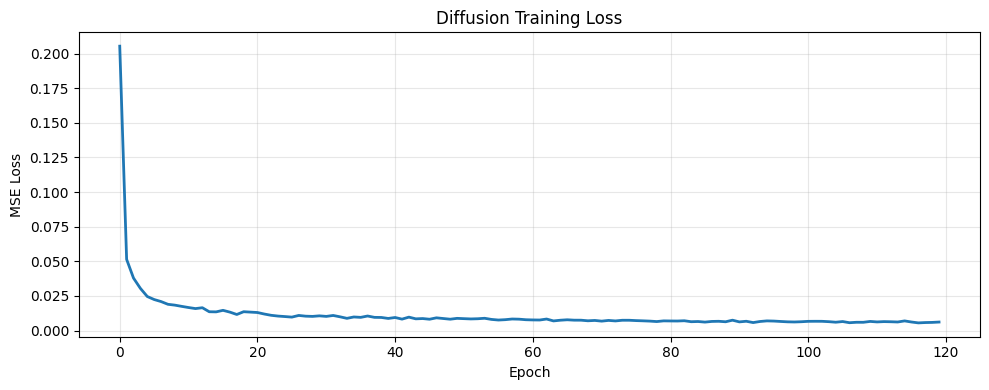

In [36]:
# === CELL 11: Plot Training Loss ===

plt.figure(figsize=(10, 4))
plt.plot(history, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Diffusion Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

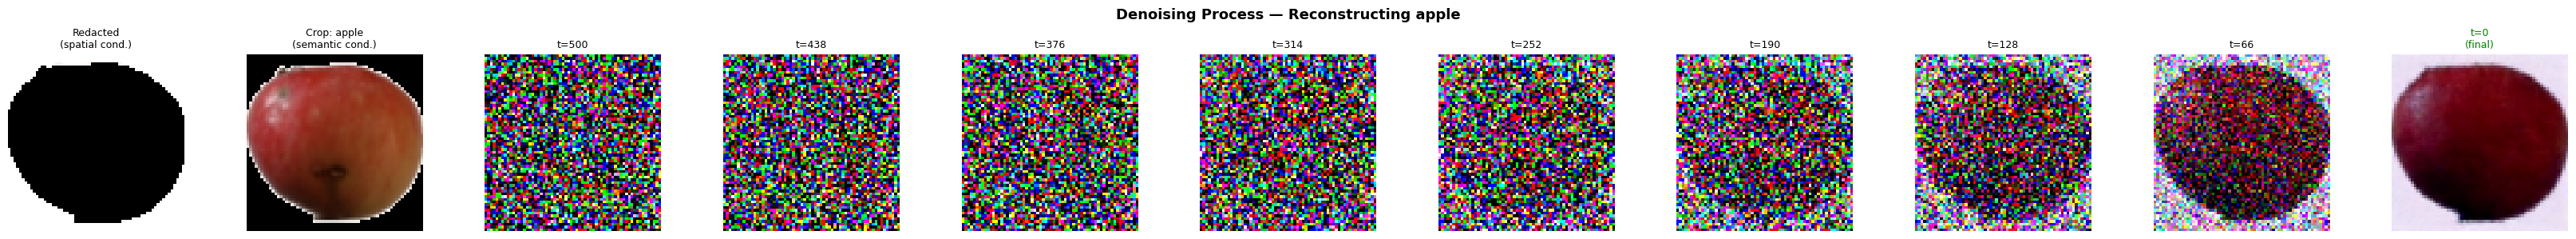

In [37]:
# === CELL 12: Visualize Denoising Process ===
ema = EMA(unet, decay=0.999)
@torch.no_grad()
def visualize_denoising(unet, fruit_encoder, scheduler, test_loader, device, n_steps=8):
    """
    Show the step-by-step denoising process:
    pure noise → ... → final generated image
    """
    unet.eval()
    fruit_encoder.eval()

    images, labels = next(iter(test_loader))
    img = images[0:1].to(device)
    label = labels[0].item()

    masks, crops, redacted = create_mask_and_crop_batch(img)

    #wrap everything
    ema.apply(unet)

    # Generate with intermediate snapshots
    result, intermediates = scheduler.sample(
        unet, fruit_encoder, crops, redacted, masks,
        return_intermediates=True, intermediate_steps=n_steps
    )

    ema.restore(unet)
    #wrap everything

    # Plot
    n = len(intermediates)
    fig, axes = plt.subplots(1, n + 2, figsize=(3 * (n + 2), 3))

    # Show the conditioning inputs first
    axes[0].imshow(redacted[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0].set_title('Redacted\n(spatial cond.)', fontsize=9)
    axes[0].axis('off')

    axes[1].imshow(crops[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1].set_title(f'Crop: {CLASS_NAMES[label]}\n(semantic cond.)', fontsize=9)
    axes[1].axis('off')

    # Show denoising steps
    for i, inter in enumerate(intermediates):
        axes[i + 2].imshow(inter[0].permute(1, 2, 0).clamp(0, 1).numpy())
        step_num = scheduler.num_timesteps - i * (scheduler.num_timesteps // n_steps)
        axes[i + 2].set_title(f't={step_num}', fontsize=9)
        axes[i + 2].axis('off')

    axes[-1].set_title('t=0\n(final)', fontsize=9, color='green')

    plt.suptitle(f'Denoising Process — Reconstructing {CLASS_NAMES[label]}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_denoising(unet, fruit_encoder, scheduler, test_loader, device)

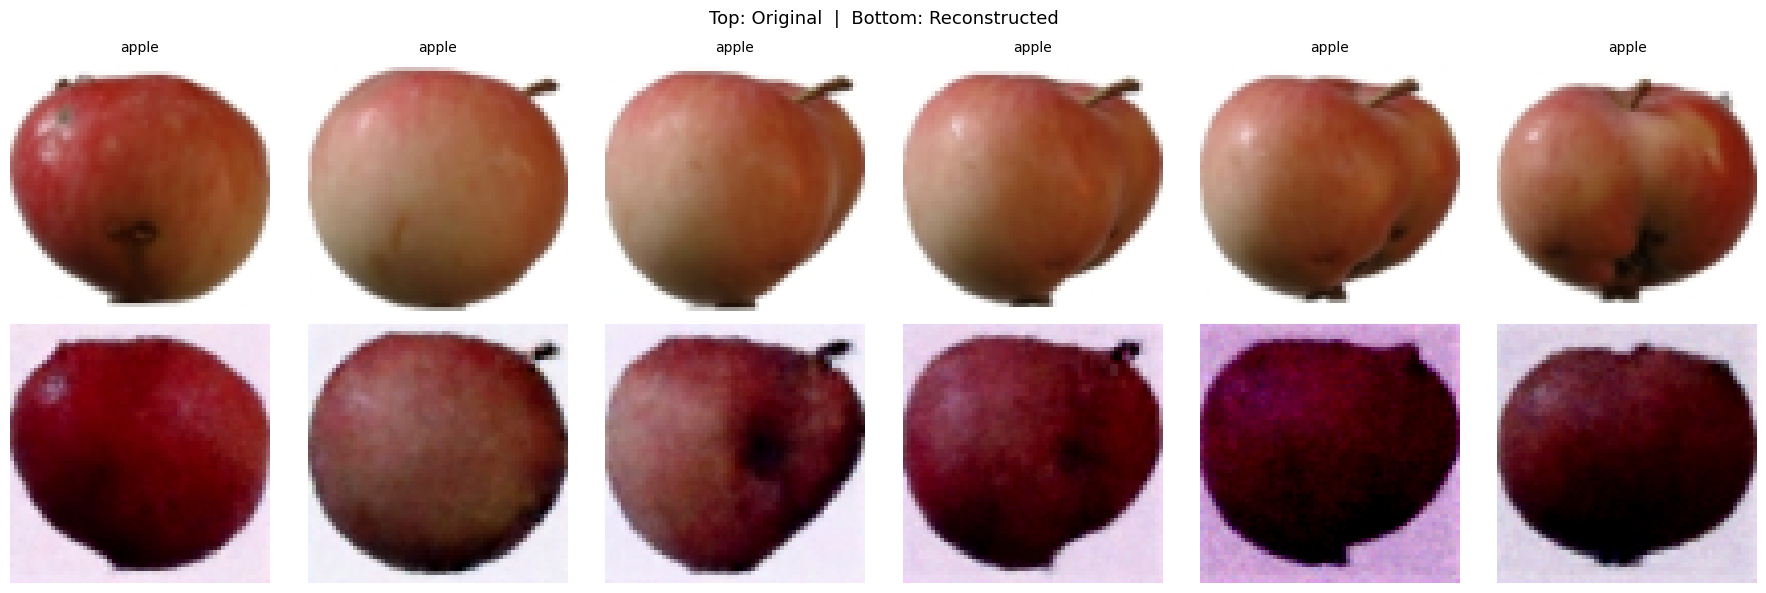

In [38]:
# === CELL 13: Reconstruction — Encode & Regenerate Same Fruit ===

@torch.no_grad()
def show_reconstructions(unet, fruit_encoder, scheduler, test_loader, device, n=6):
    """
    Reconstruct test images: use each image's own crop as conditioning.
    Shows how well the model has learned each fruit type.
    """
    unet.eval()
    fruit_encoder.eval()

    images, labels = next(iter(test_loader))
    images = images[:n].to(device)

    masks, crops, redacted = create_mask_and_crop_batch(images)
    #wrap everything
    ema.apply(unet)
    results = scheduler.sample(unet, fruit_encoder, crops, redacted, masks)
    ema.restore(unet)
    #wrap everything


    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle('Top: Original  |  Bottom: Reconstructed', fontsize=13)

    for i in range(n):
        axes[0, i].imshow(images[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[0, i].set_title(CLASS_NAMES[labels[i].item()], fontsize=10)
        axes[0, i].axis('off')

        axes[1, i].imshow(results[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

show_reconstructions(unet, fruit_encoder, scheduler, test_loader, device)

In [39]:
def find_samples_per_class(loader, class_to_idx, n_per_class=3):
    """
    Search across ALL batches to reliably find n samples of each class.
    Returns dict: {class_idx: (images_tensor, labels_tensor)}
    """
    collected = {idx: [] for idx in class_to_idx.values()}
    target_n = n_per_class

    for images, labels in loader:
        for cls_idx in collected:
            if len(collected[cls_idx]) >= target_n:
                continue
            mask = labels == cls_idx
            if mask.any():
                cls_imgs = images[mask]
                need = target_n - len(collected[cls_idx])
                collected[cls_idx].extend(cls_imgs[:need])

        # Check if we have enough of everything
        if all(len(v) >= target_n for v in collected.values()):
            break

    # Stack into tensors
    result = {}
    for cls_idx, img_list in collected.items():
        if len(img_list) > 0:
            result[cls_idx] = torch.stack(img_list)

    return result

/tmp/ipykernel_2720/1752697952.py:65: UserWarning: Glyph 127818 (\N{TANGERINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2720/1752697952.py:65: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


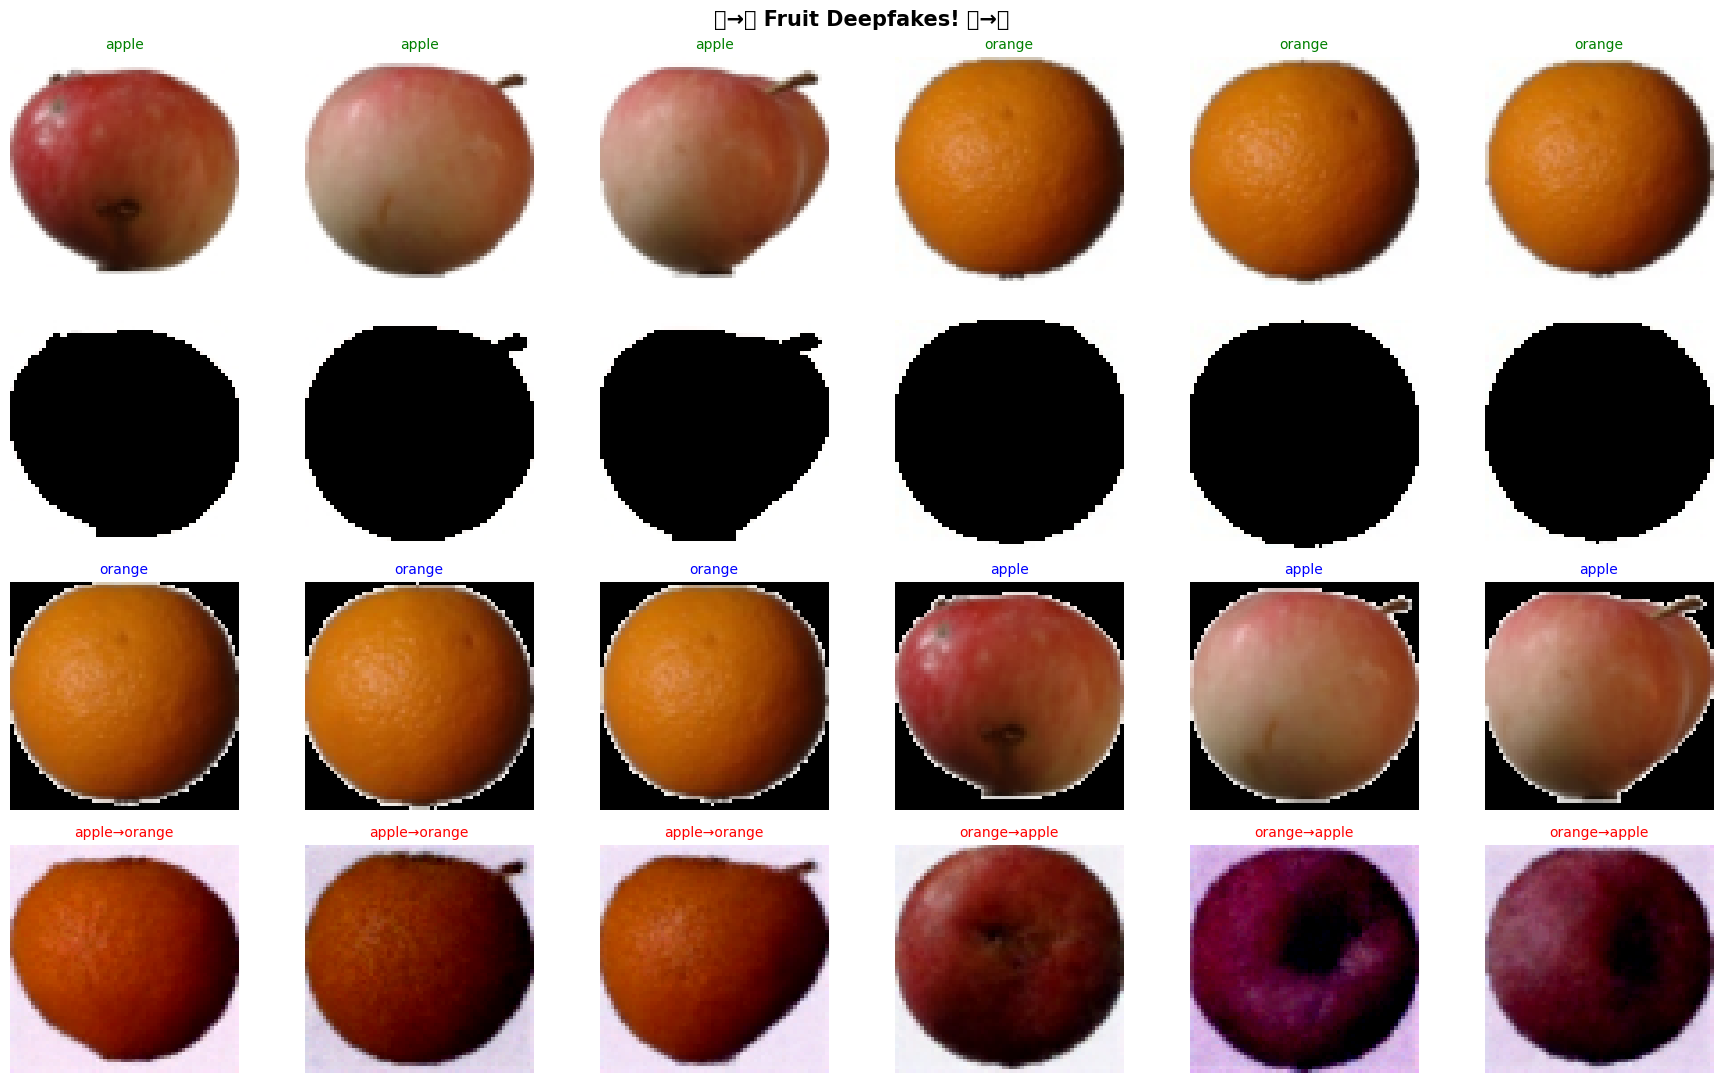

In [40]:
# === CELL 14: DEEPFAKE — Swap the Fruit! ===

@torch.no_grad()
def deepfake_diffusion(unet, fruit_encoder, scheduler, test_loader, device, n=6):
    """
    The deepfake trick:
    - Take an apple image → extract background
    - Condition on an ORANGE embedding
    - Diffusion fills the hole with an orange

    Shows: original | redacted background | source fruit crop | deepfake result
    """
    unet.eval()
    fruit_encoder.eval()

    samples = find_samples_per_class(test_loader, train_dataset.class_to_idx, n_per_class=n//2)
    apple_class = train_dataset.class_to_idx['apple']
    orange_class = train_dataset.class_to_idx['orange']

    apple_imgs = samples[apple_class]
    orange_imgs = samples[orange_class]

    # Targets: apples then oranges. Sources (opposite): oranges then apples.
    n_each = min(n // 2, len(apple_imgs), len(orange_imgs))
    target_images = torch.cat([apple_imgs[:n_each], orange_imgs[:n_each]]).to(device)
    target_labels_list = [apple_class] * n_each + [orange_class] * n_each

    source_images = torch.cat([orange_imgs[:n_each], apple_imgs[:n_each]]).to(device)
    source_labels_list = [orange_class] * n_each + [apple_class] * n_each

    masks, _, redacted = create_mask_and_crop_batch(target_images)
    _, source_crops, _ = create_mask_and_crop_batch(source_images)

    ema.apply(unet)
    results = scheduler.sample(unet, fruit_encoder, source_crops, redacted, masks)
    ema.restore(unet)

    # Visualize
    actual_n = len(target_labels_list)
    fig, axes = plt.subplots(4, actual_n, figsize=(3 * actual_n, 11))
    row_labels = ['Original', 'Redacted\n(background)', 'Source fruit\n(conditioning)', 'DEEPFAKE']

    for i in range(actual_n):
        axes[0, i].imshow(target_images[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[0, i].set_title(CLASS_NAMES[target_labels_list[i]], fontsize=10, color='green')

        axes[1, i].imshow(redacted[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())

        axes[2, i].imshow(source_crops[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[2, i].set_title(CLASS_NAMES[source_labels_list[i]], fontsize=10, color='blue')

        axes[3, i].imshow(results[i].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
        axes[3, i].set_title(
            f'{CLASS_NAMES[target_labels_list[i]]}→{CLASS_NAMES[source_labels_list[i]]}',
            fontsize=10, color='red'
        )

        for row in range(4):
            axes[row, i].axis('off')

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=80, va='center')

    plt.suptitle('🍊→🍎 Fruit Deepfakes! 🍎→🍊', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

deepfake_diffusion(unet, fruit_encoder, scheduler, test_loader, device)

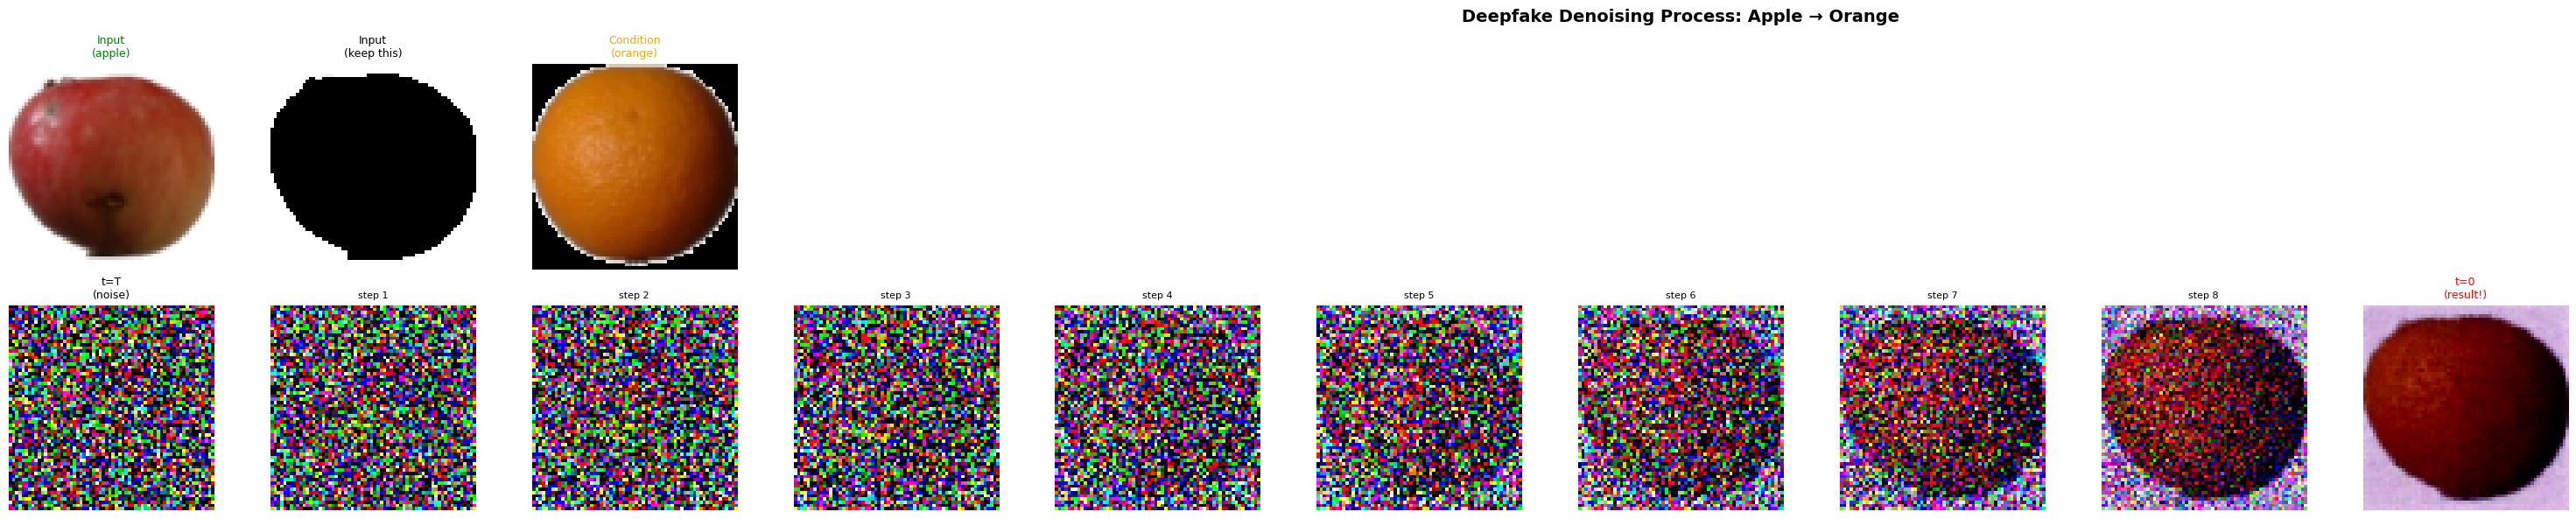

In [41]:
# === CELL 15: Visualize Deepfake Denoising Step-by-Step ===

@torch.no_grad()
def visualize_deepfake_process(unet, fruit_encoder, scheduler, test_loader,
                                device, n_steps=10):
    """
    Show the full deepfake process step by step:
    pure noise → gradually becomes the swapped fruit
    """
    unet.eval()
    fruit_encoder.eval()

    samples = find_samples_per_class(test_loader, train_dataset.class_to_idx, n_per_class=1)
    apple_class = train_dataset.class_to_idx['apple']
    orange_class = train_dataset.class_to_idx['orange']

    if apple_class not in samples or orange_class not in samples:
        print("ERROR: dataset doesn't contain both classes.")
        return

    target_img = samples[apple_class][:1].to(device)
    source_img = samples[orange_class][:1].to(device)

    masks_t, _, redacted_t = create_mask_and_crop_batch(target_img)
    _, source_crop, _ = create_mask_and_crop_batch(source_img)

    ema.apply(unet)
    result, intermediates = scheduler.sample(
        unet, fruit_encoder, source_crop, redacted_t, masks_t,
        return_intermediates=True, intermediate_steps=n_steps
    )
    ema.restore(unet)

    # Plot
    fig, axes = plt.subplots(2, n_steps + 3, figsize=(3 * (n_steps + 3), 6))

    # Row 1: the setup
    axes[0, 0].imshow(target_img[0].cpu().permute(1, 2, 0).numpy())
    axes[0, 0].set_title('Input\n(apple)', fontsize=9, color='green')
    axes[0, 1].imshow(redacted_t[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, 1].set_title('Input\n(keep this)', fontsize=9)
    axes[0, 2].imshow(source_crop[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, 2].set_title('Condition\n(orange)', fontsize=9, color='orange')

    for i in range(n_steps + 3):
        axes[0, i].axis('off')
        if i >= 3:
            axes[0, i].set_visible(False)

    # Row 2: denoising progression
    for i, inter in enumerate(intermediates):
        axes[1, i].imshow(inter[0].permute(1, 2, 0).clamp(0, 1).numpy())
        if i == 0:
            axes[1, i].set_title('t=T\n(noise)', fontsize=9)
        elif i == len(intermediates) - 1:
            axes[1, i].set_title('t=0\n(result!)', fontsize=9, color='red')
        else:
            axes[1, i].set_title(f'step {i}', fontsize=8)
        axes[1, i].axis('off')

    # Hide unused axes in row 2
    for i in range(len(intermediates), n_steps + 3):
        axes[1, i].set_visible(False)

    plt.suptitle('Deepfake Denoising Process: Apple → Orange',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_deepfake_process(unet, fruit_encoder, scheduler, test_loader, device)

In [42]:
# === CELL 16: Save Models ===

def save_checkpoint(unet, fruit_encoder, history, filename='diffusion_checkpoint.pt'):
    torch.save({
        'unet_state': unet.state_dict(),
        'encoder_state': fruit_encoder.state_dict(),
        'history': history,
        'config': {
            'img_size': IMG_SIZE,
            'embed_dim': EMBED_DIM,
            'base_channels': BASE_CHANNELS,
            'num_timesteps': NUM_TIMESTEPS,
        }
    }, filename)
    print(f"Checkpoint saved to {filename}")

save_checkpoint(unet, fruit_encoder, history)

Checkpoint saved to diffusion_checkpoint.pt
